## Part 1: Exploratory Data Analysis (EDA)

In [72]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings("ignore")

In [73]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline


In [74]:

from sklearn.model_selection import KFold
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import optuna

In [75]:
# find the root from the project directory
def find_project_root(path):
    """Find the root directory of a Git repository."""
    path = Path(path).resolve()
    while True:
        if (path / '.git').exists():
            return path
        if path.parent == path:
            break
        path = path.parent
    return None

In [76]:
# use pathlib for better path management
# Find the root directory of the project
CURR_DIR = Path().resolve()
ROOT_DIR = find_project_root(CURR_DIR)

# Define the data directory
DATA_DIR = ROOT_DIR / 'data'

In [77]:
import logging
from logging.handlers import RotatingFileHandler
import os

def setup_logger():
    logger = logging.getLogger('Customer_Segmentation')
    logger.setLevel(logging.DEBUG)

    # Create console handler
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)  # Changed to DEBUG

    # Ensure logs directory exists
    log_dir = os.path.join(ROOT_DIR, "logs")
    os.makedirs(log_dir, exist_ok=True)

    # Rotating File Handler
    log_files = os.path.join(log_dir, "Customer_Segmentation_logs")
    file_handler = RotatingFileHandler(log_files, maxBytes=2000, backupCount=3)
    file_handler.setLevel(logging.DEBUG)

    # Set format of the logs
    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    # Add handlers to the logger
    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    return logger

logger = setup_logger()


In [78]:
try:
    # Load the customer data
    customer_data = pd.read_csv(os.path.join(DATA_DIR, 'raw_data', 'mall_customers.csv'))
    logger.info(f"Data has been imported from '{DATA_DIR}' successfully")

    # Create a copy of the data
    df = customer_data.copy(deep=True)
except FileNotFoundError as e:
    logger.error(f"File not found at {DATA_DIR}:{e}")


2025-09-29 10:48:58,886 - Customer_Segmentation - INFO - Data has been imported from 'D:\CODE\MY_PROJECTS\00_MACHINE_TASKS\Customer_Segmenation_DataDivr\data' successfully
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 177, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs' -> 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs.1'
Call stack:
  File "c:\Users\anilj.ANI

In [79]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [80]:
df = df.drop(columns = ['CustomerID'])
df['Annual Income (k$)'] = df['Annual Income (k$)'] * 1000
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


In [81]:
# normalize column names for convenience
new_column_name = {
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}
df = df.rename(columns=new_column_name)
logger.info(f"column names changed: {new_column_name}")
df

2025-09-29 10:48:58,966 - Customer_Segmentation - INFO - column names changed: {'Gender': 'gender', 'Age': 'age', 'Annual Income (k$)': 'annual_income', 'Spending Score (1-100)': 'spending_score'}
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 177, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs' -> 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs.1'
Call stack:
 

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


In [82]:
logger.info(f"created data version: 'customer_data_version_01.csv' in {Path(DATA_DIR /'data_versions')}")
df.to_csv(DATA_DIR / 'data_versions' / 'customer_data_version_01.csv', index=False)

2025-09-29 10:48:59,010 - Customer_Segmentation - INFO - created data version: 'customer_data_version_01.csv' in D:\CODE\MY_PROJECTS\00_MACHINE_TASKS\Customer_Segmenation_DataDivr\data\data_versions
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 177, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs' -> 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs.1'
Call stack:

In [83]:
# selecting numerical features and categorical features

def get_feature_lists(data: pd.DataFrame):
    """get the list of numerical and categorical features"""
    numerical_features = [col for col in df.select_dtypes(include="number").columns if col != "CustomerID"]
    categorical_features = df.select_dtypes(include="object").columns.tolist()
    
    logger.info(f"numerical features of data: {numerical_features}")
    logger.info(f"categorical features of data: {categorical_features}")
    return numerical_features, categorical_features

In [84]:
numerical_features, categorical_features = get_feature_lists(df)

2025-09-29 10:48:59,040 - Customer_Segmentation - INFO - numerical features of data: ['age', 'annual_income', 'spending_score']
2025-09-29 10:48:59,040 - Customer_Segmentation - INFO - numerical features of data: ['age', 'annual_income', 'spending_score']
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 177, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs' -> 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_

### 1.1 Univariate Analysis

### Numerical Features

first step is to explore statistical and numerical messures

In [85]:
# measure of dispersion
df.describe()

,age,annual_income,spending_score
count,200.000000,200.000000,200.000000
mean,38.850000,60560.000000,50.200000
std,13.969007,26264.721165,25.823522
min,18.000000,15000.000000,1.000000
25%,28.750000,41500.000000,34.750000
50%,36.000000,61500.000000,50.000000
75%,49.000000,78000.000000,73.000000
max,70.000000,137000.000000,99.000000


##### skewness & kurtosis

In [86]:
def get_shape_measures(data: pd.DataFrame, feature_list: list[str]) -> dict:
    """Return skewness and kurtosis value of numerical feature
        data: data_frame
        feature_list: numerical feature names
        return : dictionary of skewness and kurtosis value of features and their descriptions
    """
    measure_of_shape = {}
    for feature in feature_list:
        shape = {}
        skew = data[feature].skew()
        kurt = data[feature].kurtosis()

        shape["skew"] = skew
        if skew < -1:
            shape["skew_description"] = "Highly left-skewed"
        elif skew < -0.5:
            shape["skew_description"] = "Moderately left-skewed"
        elif skew < 0:
            shape["skew_description"] = "Slightly left-skewed"
        elif skew == 0:
            shape["skew_description"] = "Symmetric"
        elif skew < 0.5:
            shape["skew_description"] = "Slightly right-skewed"
        elif skew < 1:
            shape["skew_description"] = "Moderately right-skewed"
        else:
            shape["skew_description"] = "Highly right-skewed"

        shape["kurt"] = kurt
        if kurt < 2:
            shape["kurt_description"] = "Very platykurtic(flat)"
        elif kurt < 3:
            shape["kurt_description"] = "Platykurtic(less peaked)"
        elif kurt == 3:
            shape["kurt_description"] = "Mesokurtic(normal)"
        elif kurt < 4:
            shape["kurt_description"] = "Leptokurtic(more peaked)"
        else:
            shape["kurt_description"] = "Very leptokurtic(very peaked)"
        
        measure_of_shape[feature] = shape
    return measure_of_shape

In [87]:
measure_shape = get_shape_measures(df, numerical_features)
pd.DataFrame(measure_shape)

,age,annual_income,spending_score
skew,0.485569,0.321843,-0.04722
skew_description,Slightly right-skewed,Slightly right-skewed,Slightly left-skewed
kurt,-0.671573,-0.098487,-0.826629
kurt_description,Very platykurtic(flat),Very platykurtic(flat),Very platykurtic(flat)


visualization of univariate analysis

In [88]:
# univariate plot of numerical features
def univariate_numerical_plots(data: pd.DataFrame, feature: str) -> plt.subplot:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
    
    # Histogram
    sns.histplot(data=data, x=feature, ax=axes[0, 0], kde=True)
    axes[0, 0].set_title(f"Histogram of {feature}")
    
    # Density Plot
    sns.kdeplot(data=data, x=feature, ax=axes[0, 1], fill=True)
    axes[0, 1].set_title(f"Density Plot of {feature}")
    
    # Boxplot
    sns.boxplot(data=data, x=feature, ax=axes[1, 0])
    axes[1, 0].set_title(f"Boxplot of {feature}")
    
    # QQ Plot
    # Note: Seaborn does not have a built-in QQ plot function.
    # We will use scipy.stats.probplot instead.
    from scipy import stats
    stats.probplot(data[feature], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"QQ Plot of {feature}")
    plt.suptitle(f"Univariate plot: {feature}")
    
    plt.tight_layout()
    plt.show()

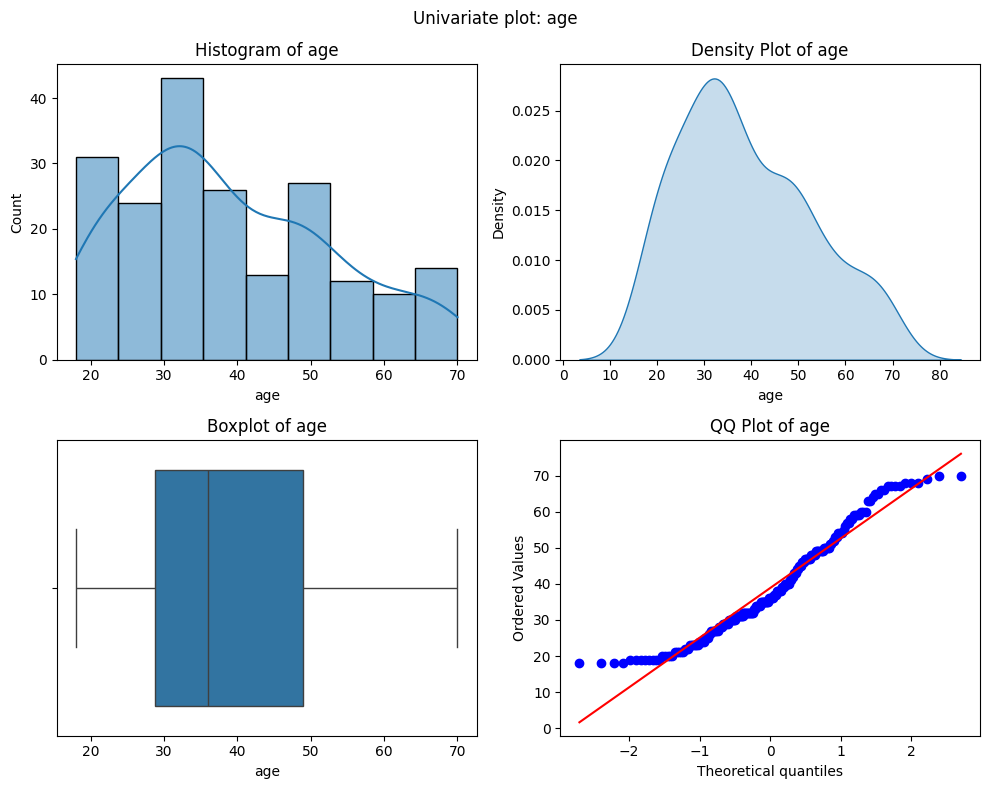

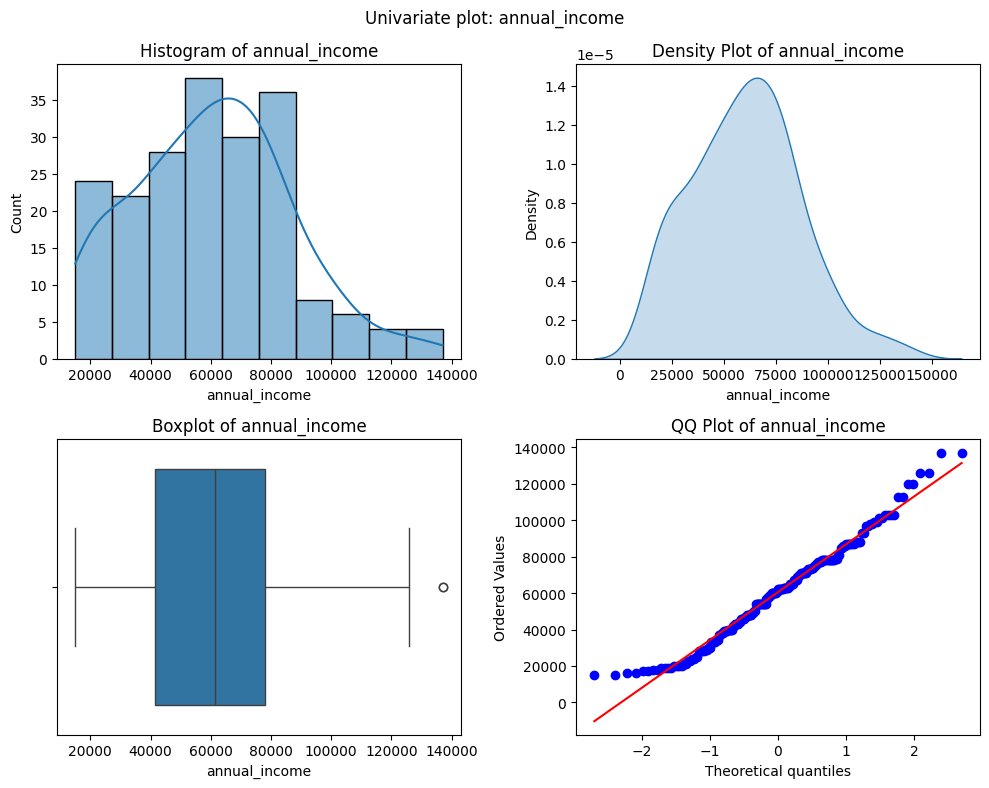

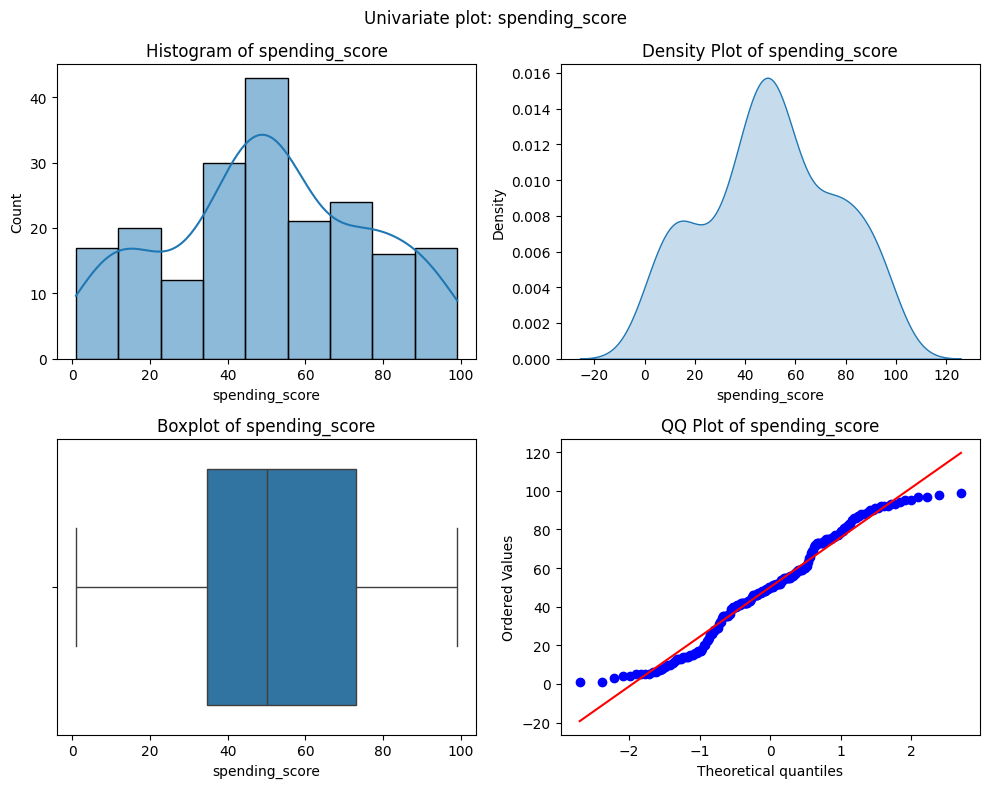

In [89]:
for feature in numerical_features:
    univariate_numerical_plots(df, feature)

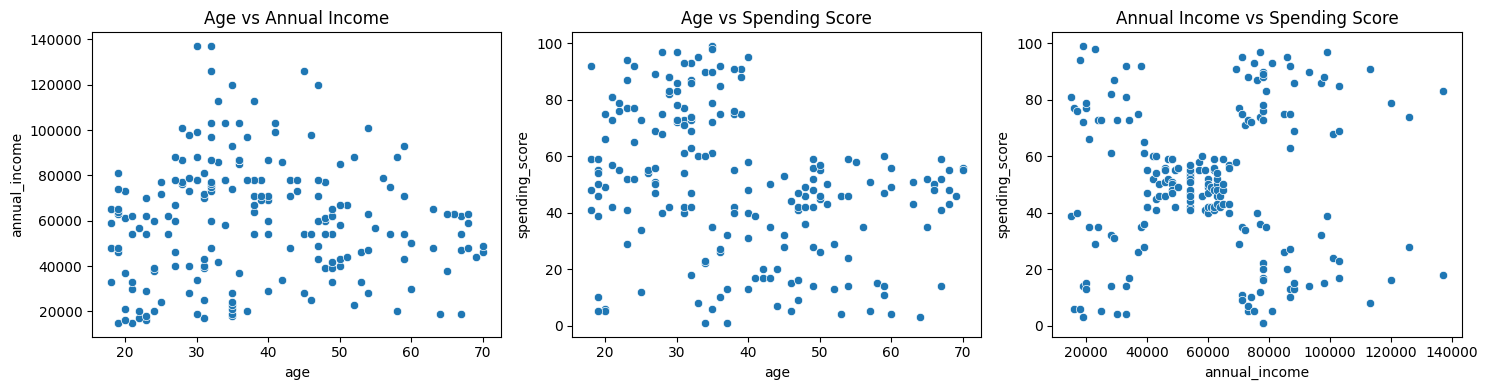

In [90]:
# Scatter plots
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='annual_income', data=df)
plt.title('Age vs Annual Income')

plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='spending_score', data=df)
plt.title('Age vs Spending Score')

plt.subplot(1, 3, 3)
sns.scatterplot(x='annual_income', y='spending_score', data=df)
plt.title('Annual Income vs Spending Score')

plt.tight_layout()
plt.show()

from the statistical messures and visualization of univariate analysis:
- it is found that almost all numerical features are lightly right skewed
- so we need to to feature transformation suitably, log transformation or yeo-johnson
- outliers are not found in any numerical features except in annual income (1), presumably the not a anomaly but the normal data

### Categorical Features

In [91]:
def univariate_categorical_plots(data: pd.DataFrame, categorical_features: list[str]) -> None:
    ncols = 2
    nrows = (len(categorical_features) + ncols - 1) // ncols
    
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 6*nrows))
    
    for i, feature in enumerate(categorical_features):
        if nrows == 1:  # if there's only one row
            ax = axes[i % ncols]
        else:
            ax = axes[i // ncols, i % ncols]
        
        sns.countplot(data=data, x=feature, ax=ax)
        ax.set_title(f"Count Plot: {feature}")
    
    # hide any unused subplots
    for i in range(len(categorical_features), nrows * ncols):
        if nrows == 1:
            ax = axes[i % ncols]
        else:
            ax = axes[i // ncols, i % ncols]
        ax.axis('off')
    
    plt.suptitle("Univariate plots of Categorical features")
    plt.tight_layout()
    
    plt.show()

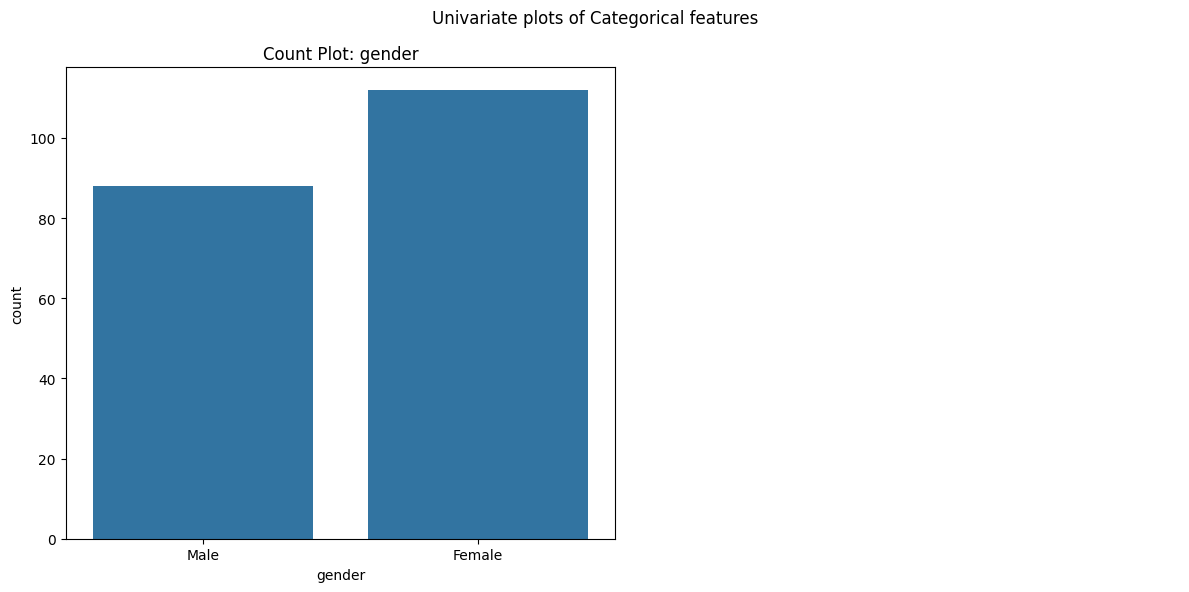

In [92]:
univariate_categorical_plots(df, categorical_features)

from the count plot we could see that :
- Gender is slightly imbalanced: Female (112) vs Male (88) → for clustering, this is usually fine since clustering is unsupervised
- or we could use clustering algorithm robust to outliers such as DBSCAN

---

### 1.2 Bivariate Analysis

#### Numerical vs Numerical

In [93]:
def correlation_matrix(data: pd.DataFrame, numerical_features: list[str]) -> dict:
    correlation_values = {}
    correlation_values['pearson_correlation'] = df[numerical_features].corr(method='pearson')
    correlation_values['spearman_correlation'] = df[numerical_features].corr(method='spearman')
    correlation_values['kendall_correlation'] = df[numerical_features].corr(method='kendall')
    return correlation_values

In [94]:
print(f"Pearson Correlation:\n\n")
corr_matrix_pearson = correlation_matrix(df, numerical_features)['spearman_correlation']
corr_matrix_pearson

Pearson Correlation:




,age,annual_income,spending_score
age,1.000000,0.019767,-0.34494
annual_income,0.019767,1.000000,0.00784
spending_score,-0.344940,0.007840,1.00000


In [95]:
print(f"Spearman Correlation:\n\n")
corr_matrix_spearman = correlation_matrix(df, numerical_features)['spearman_correlation']
corr_matrix_spearman

Spearman Correlation:




,age,annual_income,spending_score
age,1.000000,0.019767,-0.34494
annual_income,0.019767,1.000000,0.00784
spending_score,-0.344940,0.007840,1.00000


In [96]:
print(f"Kendall Correlation:\n")
corr_matrix_kendall = correlation_matrix(df, numerical_features)['kendall_correlation']
corr_matrix_kendall

Kendall Correlation:



,age,annual_income,spending_score
age,1.000000,0.008198,-0.210757
annual_income,0.008198,1.000000,-0.000765
spending_score,-0.210757,-0.000765,1.000000


In [97]:
print(f"Covariance of features:\n")
cov_matrix = df[numerical_features].cov()
cov_matrix

Covariance of features:



,age,annual_income,spending_score
age,195.133166,-4.548744e+03,-118.040201
annual_income,-4548.743719,6.898356e+08,6716.582915
spending_score,-118.040201,6.716583e+03,666.854271


visualization

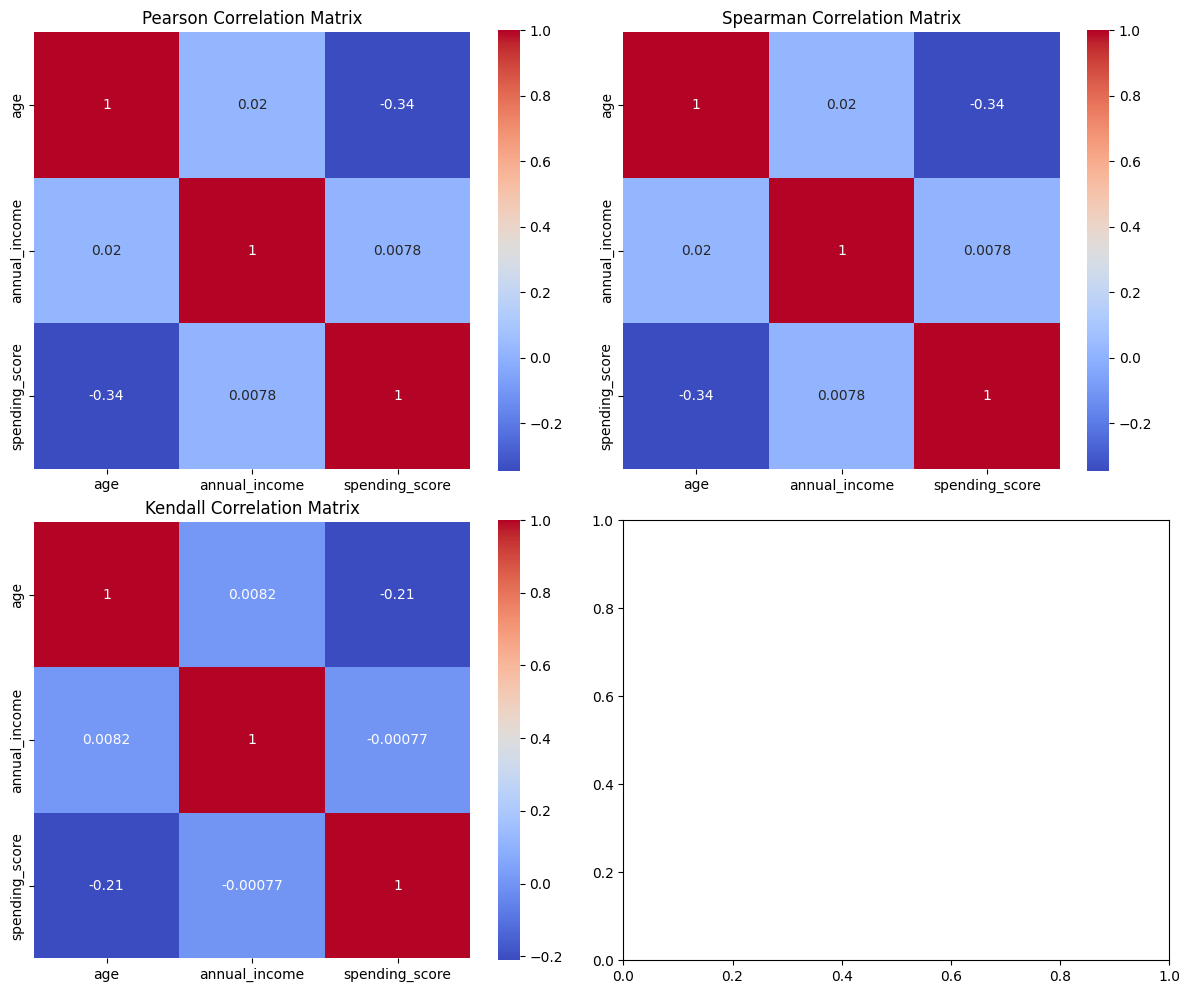

In [98]:
# Create a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the Pearson correlation matrix
sns.heatmap(corr_matrix_pearson, annot=True, cmap='coolwarm', square=True, ax=axs[0, 0])
axs[0, 0].set_title('Pearson Correlation Matrix')

# Plot the Spearman correlation matrix
sns.heatmap(corr_matrix_spearman, annot=True, cmap='coolwarm', square=True, ax=axs[0, 1])
axs[0, 1].set_title('Spearman Correlation Matrix')

# Plot the Kendall correlation matrix
sns.heatmap(corr_matrix_kendall, annot=True, cmap='coolwarm', square=True, ax=axs[1, 0])
axs[1, 0].set_title('Kendall Correlation Matrix')
'''
# Plot the covariance matrix
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', square=True, ax=axs[1, 1])
axs[1, 1].set_title('Covariance Matrix')
'''
# Layout so plots do not overlap
fig.tight_layout()

plt.show()


#### Numerical vs Categorical

##### group-wise statistics

In [99]:
# Gender vs Age

gender_age_status = df.groupby('gender')[['age']].agg([ 'mean', 'median', 'std'])
print("Gender-Age statistics:\n")
result = pd.DataFrame(gender_age_status)
result.T

Gender-Age statistics:



gender         Female       Male
age mean    38.098214  39.806818
    median  35.000000  37.000000
    std     12.644095  15.514812

In [100]:
# gender vs annual income
gender_annualincome_status = df.groupby('gender')[['annual_income']].agg([ 'mean', 'median', 'std'])
print("Gender-AnnualIncome statistics:\n")
result = pd.DataFrame(gender_annualincome_status)
result.T

Gender-AnnualIncome statistics:



gender                      Female          Male
annual_income mean    59250.000000  62227.272727
              median  60000.000000  62500.000000
              std     26011.951515  26638.373182

In [101]:
# Gender vs SpendingScore
gender_spendingscore_status = df.groupby('gender')[['spending_score']].agg([ 'mean', 'median', 'std'])
print("Gender-SpendingScore statistics:\n")
result = pd.DataFrame(gender_spendingscore_status)
result

Gender-SpendingScore statistics:



spending_score                 
                 mean median       std
gender                                
Female      51.526786   50.0  24.11495
Male        48.511364   50.0  27.89677

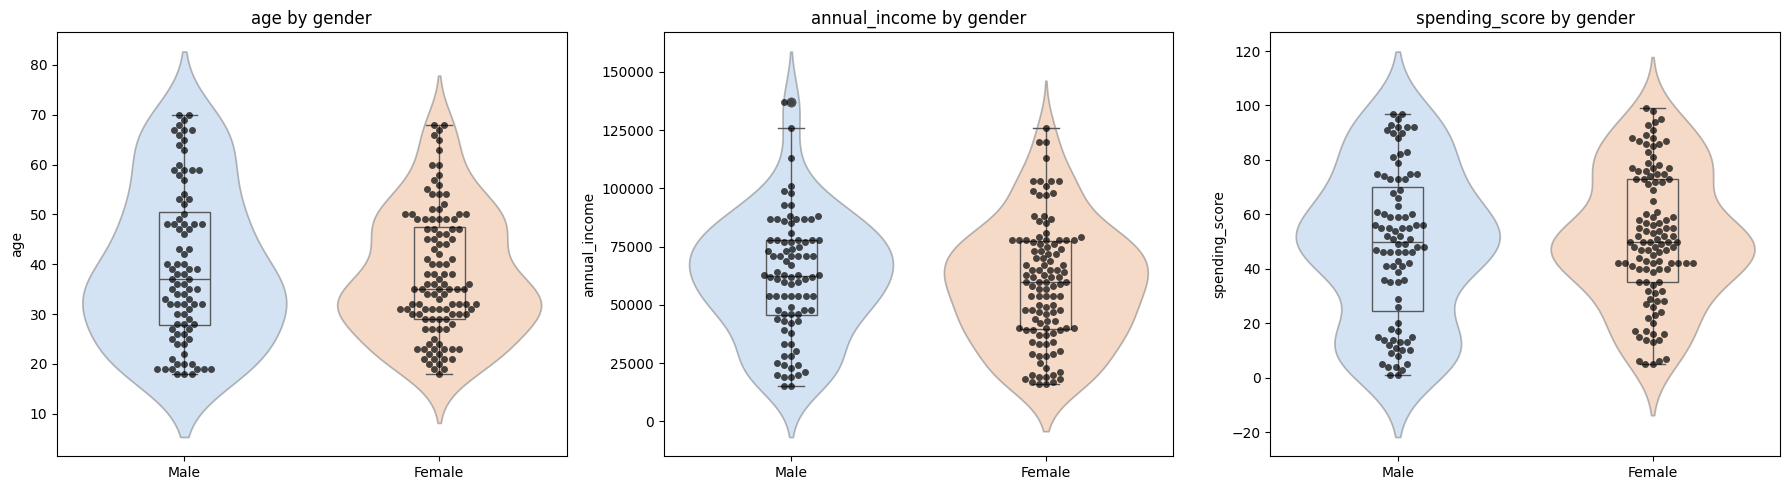

In [102]:
# Combined plot: Box + Violin + Swarm

plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    
    # Violin plot (distribution + density)
    sns.violinplot(x='gender', y=feature, data=df, inner=None, hue='gender', palette='pastel', alpha=0.5, legend=False)
    
    # Boxplot (quartiles + median)
    sns.boxplot(x='gender', y=feature, data=df, width=0.2, hue='gender', palette='Set2', showcaps=True, boxprops={'facecolor':'None'}, showfliers=True, legend=False)
    
    # Swarmplot (individual points)
    sns.swarmplot(x='gender', y=feature, data=df, color='k', alpha=0.7)
    
    plt.title(f'{feature} by gender')
    plt.xlabel('')
    plt.ylabel(feature)
    
plt.tight_layout()
plt.show()

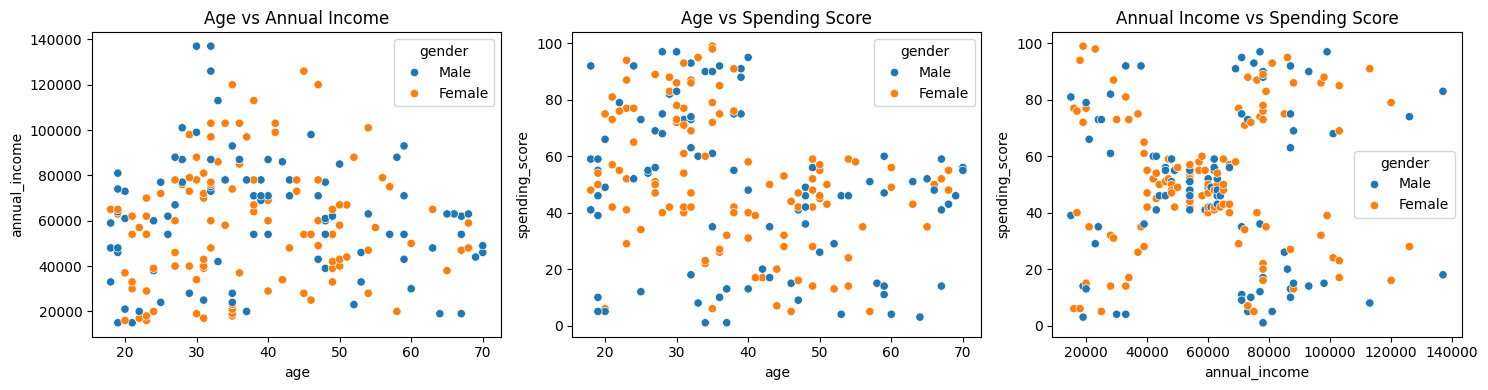

In [103]:

# Individual scatter plots
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='annual_income', data=df, hue='gender', hue_order=['Male', 'Female'])
plt.title('Age vs Annual Income')

plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='spending_score', data=df, hue='gender', hue_order=['Male', 'Female'])
plt.title('Age vs Spending Score')

plt.subplot(1, 3, 3)
sns.scatterplot(x='annual_income', y='spending_score', data=df, hue='gender', hue_order=['Male', 'Female'])
plt.title('Annual Income vs Spending Score')

plt.tight_layout()
plt.show()



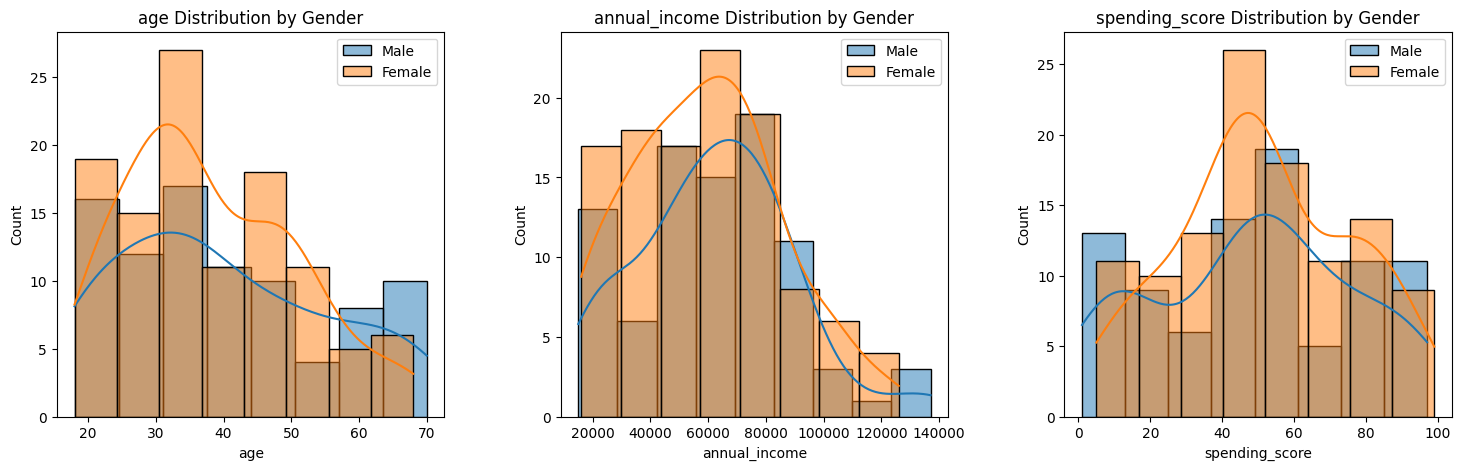

In [104]:
# Distribution plots by category (Optional)
plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    for gender in df['gender'].unique():
        sns.histplot(df[df['gender']==gender][feature], label=gender, kde=True, alpha=0.5)
    plt.title(f'{feature} Distribution by Gender')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()
plt.subplots_adjust(wspace=0.3, hspace=0.3)  
plt.show()

## Multivariate Analysis

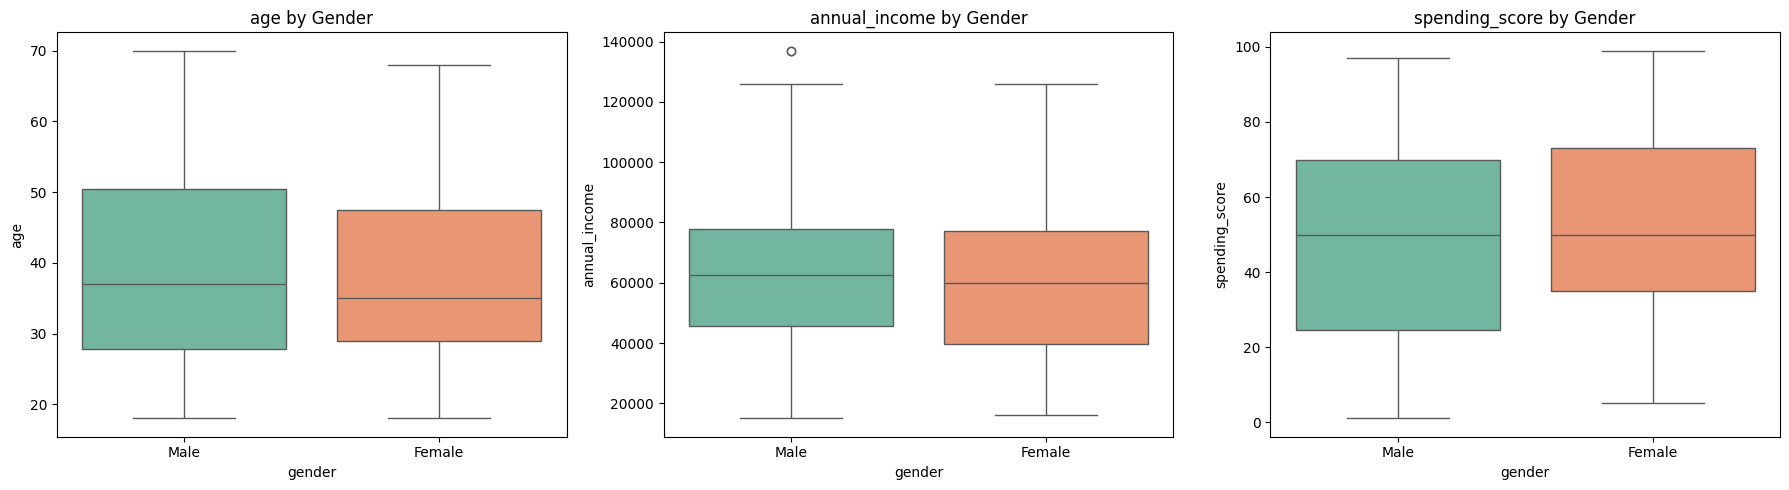

In [105]:
## 4.2 Boxplots
plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='gender', y=feature, data=df, palette="Set2")
    plt.title(f"{feature} by Gender")
plt.tight_layout()
plt.show()


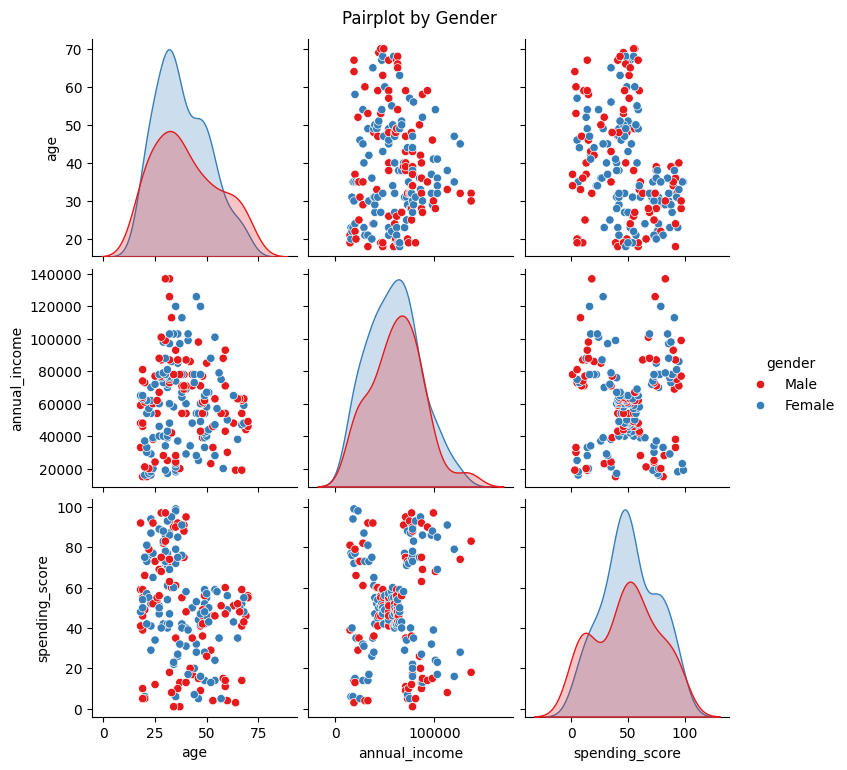

In [106]:
## 6.1 Pairplot Colored by Gender
sns.pairplot(df, vars=numerical_features, hue="gender", diag_kind='kde', palette="Set1")
plt.suptitle("Pairplot by Gender", y=1.02)
plt.show()

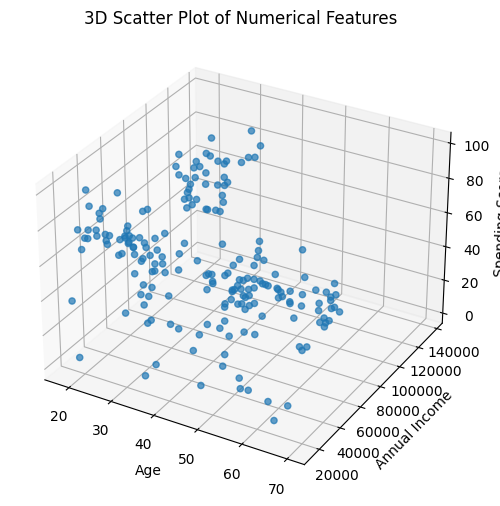

In [107]:
## 3.3 3D Scatter Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['age'], df['annual_income'], df['spending_score'], alpha=0.7)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')
plt.title("3D Scatter Plot of Numerical Features")
plt.show()

(c) Multicollinearity Check (VIF)

In [108]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[numerical_features]
X = sm.add_constant(X)  # add intercept
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

          Feature        VIF
0           const  23.359560
1             age   1.120023
2   annual_income   1.000192
3  spending_score   1.119961



The VIF values indicate the level of multicollinearity between the features. A high VIF value (typically > 5 or 10) suggests that a feature is highly correlated with one or more other features.

**Observations**:
Based on the VIF values you provided:

- The constant term has a very high VIF value (23.359560), which is not unusual.
- The Age feature has a relatively low VIF value (1.120023), indicating low correlation with other features.
- The AnnualIncome feature has a very low VIF value (1.000192), suggesting almost no correlation with other features.
- The SpendingScore feature also has a relatively low VIF value (1.119961), indicating low correlation with other features.

**Conclusion**:
Overall, the VIF values suggest that there is no significant multicollinearity between the features in your dataset. This is a good indication that your features are relatively independent and can be used together in a model without worrying about multicollinearity issues.


### Dimensionality Reduction for visualizig the underlying data relationships:

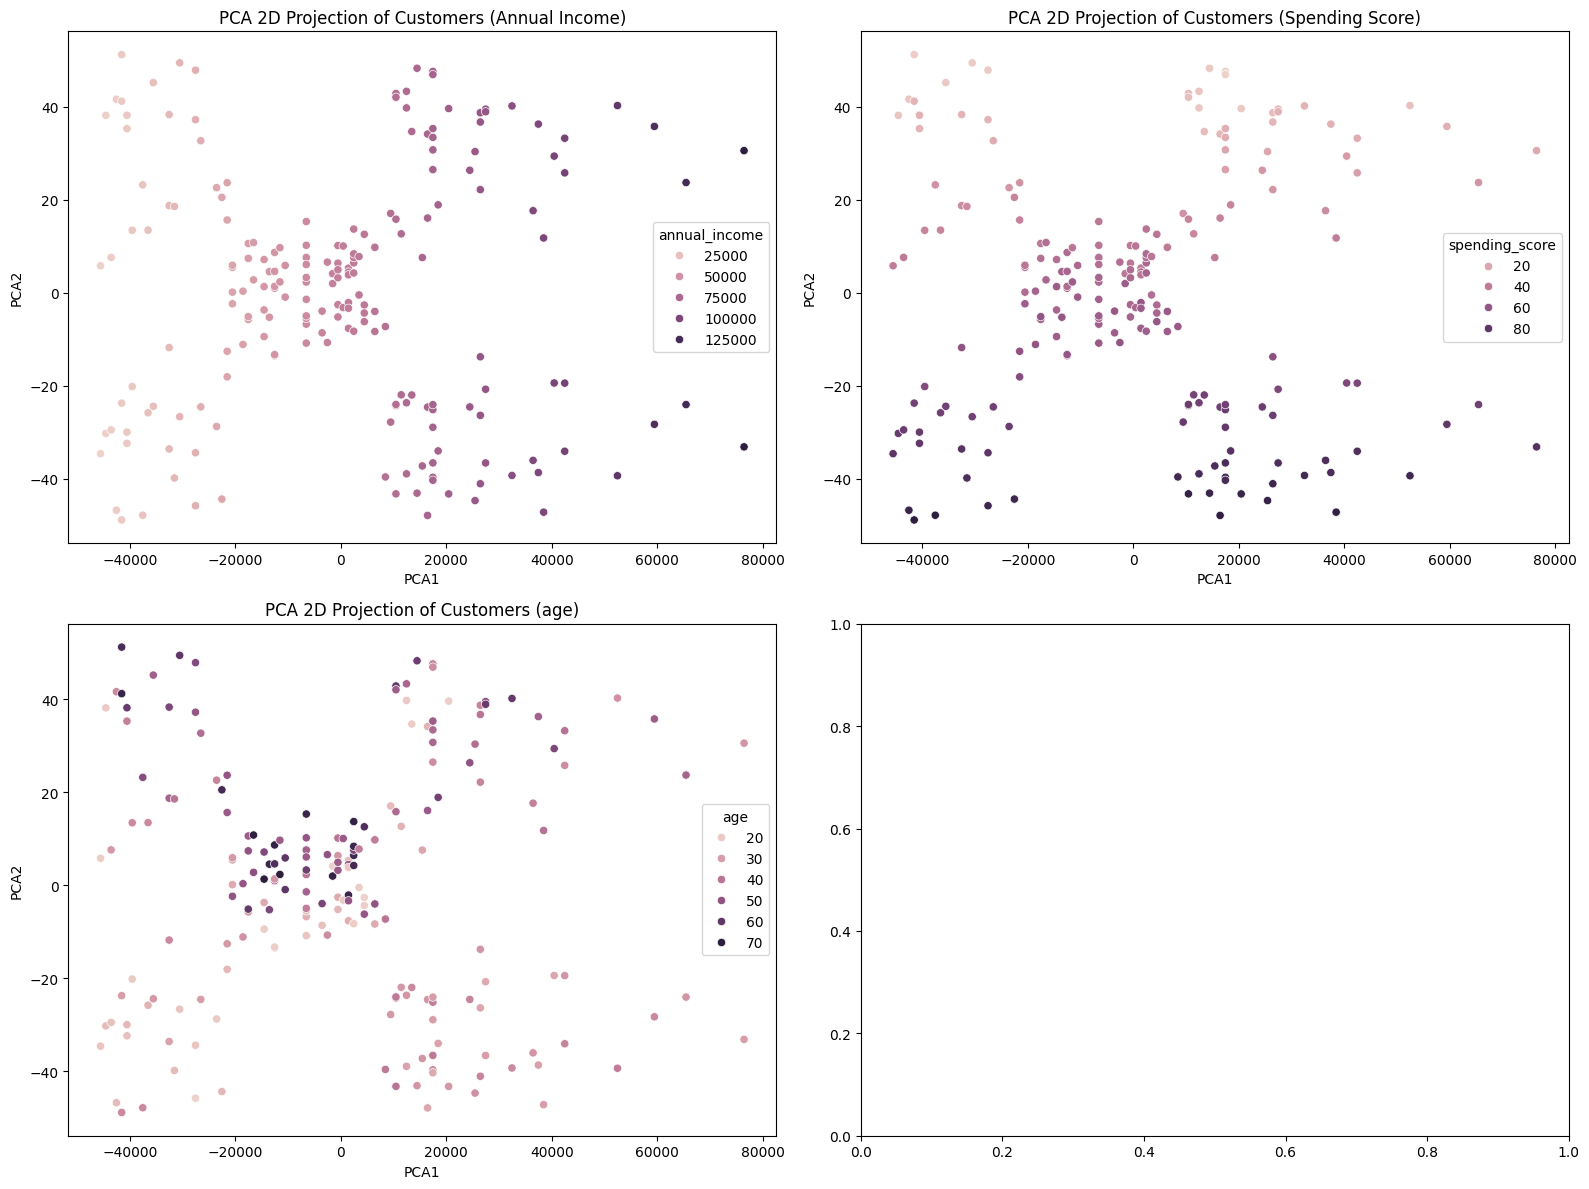

In [109]:
from sklearn.decomposition import PCA
# import seaborn as sns
# import matplotlib.pyplot as plt

data_copy_pca_visual = df.copy(deep=True)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_copy_pca_visual[numerical_features])

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Increased figsize height to accommodate 2x2 subplots

sns.scatterplot(x='PCA1', y='PCA2', hue='annual_income', data=df, ax=axs[0, 0])
axs[0, 0].set_title("PCA 2D Projection of Customers (Annual Income)")

sns.scatterplot(x='PCA1', y='PCA2', hue='spending_score', data=df, ax=axs[0, 1])
axs[0, 1].set_title("PCA 2D Projection of Customers (Spending Score)")

sns.scatterplot(x='PCA1', y='PCA2', hue='age', data=df, ax=axs[1, 0])
axs[1, 0].set_title("PCA 2D Projection of Customers (age)")
"""
sns.scatterplot(x='PCA1', y='PCA2', hue='gender_Male', data=df, ax=axs[1, 1])
axs[1, 1].set_title("PCA 2D Projection of Customers (gender_Male)")
"""
plt.tight_layout()  # Added to ensure subplots fit well in the figure
plt.show()

PCA is a dimensionality reduction technique that transforms high-dimensional data into lower-dimensional data while retaining the most important information.

Visualization:
The code is creating a 2x2 subplot matrix, where each subplot shows a scatter plot of the first two principal components (PCA1 and PCA2) colored by a different feature:

- Annual income
- Spending score
- Age
- Gender (although this subplot is currently commented out)

Insights:
By examining these plots, you can gain insights into how the different features relate to each other and to the underlying structure of the data.

Some potential insights include:

- Identifying clusters or patterns in the data
- Understanding how different features contribute to the principal components
- Visualizing relationships between features and identifying potential correlations


In [110]:
df

,gender,age,annual_income,spending_score,PCA1,PCA2
0,Male,19,15000,39,-45559.999975,5.836253
1,Male,21,15000,81,-45559.999579,-34.579234
2,Female,20,16000,6,-44560.000303,38.193379
3,Female,23,16000,77,-44559.999631,-30.215611
4,Female,31,17000,40,-43560.000045,7.643526
...,...,...,...,...,...,...
195,Female,35,120000,79,59440.000302,-28.260419
196,Female,45,126000,28,65439.999739,23.738507
197,Male,32,126000,74,65440.000272,-24.017997
198,Male,32,137000,18,76439.999726,30.603228


## Part 2: Feature Engineering

In [111]:
df = df.drop(columns=['PCA1', 'PCA2'], axis=1)
df

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


## Part 2: Clustering

### 2. 1 Missing Value Imputation

since the data does nit have any missing values we do ot nee to to the missing value imputation here


Missing Value Imputation:
In real-world datasets, missing values are common, and imputing them is crucial for accurate analysis and modeling.

Methods:
You've mentioned several imputation methods:

- Central tendency imputation: Using mean, median, or mode to impute missing values.
- Simple Imputer: A basic imputation method that replaces missing values with a specified value (e.g., mean, median, or mode).
- KNN Imputer: An imputation method that uses k-nearest neighbors to estimate missing values.
- Iterative Imputer: An imputation method that iteratively estimates missing values using a regression model.

Considerations:
When choosing an imputation method, consider the following:

- Data distribution: Different imputation methods may be more suitable for different data distributions (e.g., normal, skewed, or categorical).
- Data quality: Imputation methods can be sensitive to data quality issues, such as outliers or noisy data.
- Model complexity: Some imputation methods, like KNN or iterative imputation, can be computationally expensive and may require careful tuning.

Pipeline Integration:
Imputation can be used in a pipeline to ensure that missing values are handled consistently throughout the analysis process.


### 2. 2. Outlier Handling

In [112]:
# Yeo-Johnson transformation for Annual Income
from scipy.stats import yeojohnson
df['annual_income'], _ = yeojohnson(df['annual_income'])

in the dataset, it was identified one outlier in the Annual Income feature, which corresponds to the maximum value. This outlier is presumably not an erroneous data point but rather an extreme value that appears in the data.

Handling Outliers:
When dealing with outliers, it's essential to consider the context and the goals of your analysis. Here are some common strategies for handling outliers:

- Do nothing: If the outlier is legitimate and not an error, you may choose to leave it in the dataset.
- Transform the data: Applying transformations, such as logarithmic or square root, can help reduce the impact of outliers.
- Employ robust methods: Use robust statistical methods, such as the median and interquartile range (IQR), which are less affected by outliers.
- Remove the outlier: If the outlier is deemed to be an error or is significantly impacting your analysis, you may choose to remove it.


It is also observed in Univariate analysis the numerical features are lightly right-skewed
- we should either perform log or yeo-jhonson transformation

### 2. 3.  Encoding Categorical Features

In [113]:

# One-hot encode Gender
encoder = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = encoder.fit_transform(df[['gender']])

# Get the column names from the encoder
gender_columns = encoder.get_feature_names_out()

# Create a DataFrame from the encoded data
gender_df = pd.DataFrame(gender_encoded, columns=gender_columns)

# Merge with original dataframe
df_preprocessed = pd.concat([df.drop('gender', axis=1), gender_df], axis=1)

In [114]:
df_preprocessed


,age,annual_income,spending_score,gender_Male
0,19,797.534566,39,1.0
1,21,797.534566,81,1.0
2,20,831.782122,6,0.0
3,23,831.782122,77,0.0
4,31,865.288743,40,0.0
...,...,...,...,...
195,35,3087.626691,79,0.0
196,45,3187.209729,28,0.0
197,32,3187.209729,74,1.0
198,32,3365.577993,18,1.0


### 2.4. Scaling Numerical Features

clustering algorithms often rely on distance-based similarity measures, which can be influenced by the scale of the features.

If one feature has a much larger range than others, it can dominate the distance calculations and affect the clustering results.

Normalizing or standardizing the features can help mitigate this issue by:

1. Reducing the impact of feature scales
2. Ensuring that all features contribute equally to the distance calculations
3. Improving the overall quality of the clustering results

Common techniques for normalization and standardization include:

1. Min-Max Scaling (Normalization)
2. Standardization (Zero-Mean, Unit Variance)
3. Log Scaling

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df_preprocessed[numerical_features])

# Replace original columns with scaled values
df_preprocessed[numerical_features] = numerical_scaled
df_preprocessed.head()

,age,annual_income,spending_score,gender_Male
0,-1.424569,-1.993334,-0.434801,1.0
1,-1.281035,-1.993334,1.195704,1.0
2,-1.352802,-1.933217,-1.715913,0.0
3,-1.137502,-1.933217,1.040418,0.0
4,-0.563369,-1.874401,-0.395980,0.0


In [116]:
df_preprocessed.to_csv(DATA_DIR/'processed_data'/ 'processed_customer_data_version_01.csv', index=False)
logger.info(f"save preprocessed data: 'processed_customer_data_version_01.csv' to {Path(DATA_DIR/'processed_data')}")

2025-09-29 10:49:08,920 - Customer_Segmentation - INFO - save preprocessed data: 'processed_customer_data_version_01.csv' to D:\CODE\MY_PROJECTS\00_MACHINE_TASKS\Customer_Segmenation_DataDivr\data\processed_data
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 177, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs' -> 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs.1

---

### 2. 5. Feature Engineering Ideas

In [117]:
# Create a copy of the data
df_2 = customer_data.copy(deep=True)
df_2

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [118]:
df_2 = df_2.drop(columns = ['CustomerID'])
df_2['Annual Income (k$)'] = df_2['Annual Income (k$)'] * 1000

In [119]:
bin_labels = {
    (0, 18, 25, 40, 60, 100): ['teen', 'young_adult', 'adult', 'middle_age', 'seniors'], # binning for age
    (0, 15000, 41500, 78000, 150000): ['low-income', 'middle-income', 'high-income', 'affluent'], # binning for annual_income
    (0, 15000, 41500, 61500, 78000, 90000, 1200000): ['low-income', 'lower-middle-income', 'middle-income', 'upper-middle-income', 'high-income', 'affluent'] # binning for annual_income
}

# exmaple: get the bins and labales later for binning
first_bin = list(bin_labels.keys())[0]
first_labels = list(bin_labels.values())[0]
print(f"{first_bin} = {first_labels}")

(0, 18, 25, 40, 60, 100) = ['teen', 'young_adult', 'adult', 'middle_age', 'seniors']


In [120]:
# normalize column names for convenience
new_column_name = {
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}
df_2 = df_2.rename(columns=new_column_name)
logger.info(f"column names changed: {new_column_name}")
df_2

2025-09-29 10:49:09,014 - Customer_Segmentation - INFO - column names changed: {'Gender': 'gender', 'Age': 'age', 'Annual Income (k$)': 'annual_income', 'Spending Score (1-100)': 'spending_score'}
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 177, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs' -> 'D:\\CODE\\MY_PROJECTS\\00_MACHINE_TASKS\\Customer_Segmenation_DataDivr\\logs\\Customer_Segmentation_logs.1'
Call stack:
 

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


In [121]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   gender          200 non-null    object
 1   age             200 non-null    int64 
 2   annual_income   200 non-null    int64 
 3   spending_score  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


Age Groups

In [122]:
df_2['age_group'] = pd.cut(
    df_2['age'],
    bins = list(bin_labels.keys())[0],
    labels = list(bin_labels.values())[0]
)

Income Category

- when it comes to creating feature out of annual_income, there's a clear ranking or order in the categories (affluent > high > middle > low), ordinal encoding might be a suitable choice.
- In the context of sales and revenue generation, the order of the categories in the Annual_income_category feature is crucial.

Order of Categories:
Since customers with higher buying power are more valuable, the order of the categories should reflect this. The correct order from most important to less important is:

1. Affluent
2. High
3. Middle
4. Low

This order makes sense because affluent customers have the highest buying power, followed by high-income customers, and so on.

so we will update :
```python
bin_labels = {
    (0, 18, 25, 40, 60, 100): ['teen', 'young_adult', 'adult', 'middle_age', 'seniors'], # binning for age
    (0, 15000, 41500, 78000, 150000): ['low-income', 'middle-income', 'high-income', 'affluent'], # binning for annual_income
    (0, 15000, 41500, 61500, 78000, 90000, 1200000): ['low-income', 'lower-middle-income', 'middle-income', 'upper-middle-income', 'high-income', 'affluent'] # binning for annual_income
}
```

In [123]:
bin_labels = {
    (0, 18, 25, 40, 60, 100): ['teen', 'young_adult', 'adult', 'middle_age', 'seniors'], # binning for age
    (0, 15000, 41500, 78000, 150000): ['low-income', 'middle-income', 'high-income', 'affluent'], # binning for annual_income
    (0, 15000, 41500, 61500, 78000, 90000, 1200000): ['low-income', 'lower-middle-income', 'middle-income', 'upper-middle-income', 'high-income', 'affluent'] # binning for annual_income
}

# exmaple: get the bins and labales later for binning
first_bin = list(bin_labels.keys())[0]
first_labels = list(bin_labels.values())[0]
print(f"{first_bin} = {first_labels}")

(0, 18, 25, 40, 60, 100) = ['teen', 'young_adult', 'adult', 'middle_age', 'seniors']


In [124]:
df_2['annual_income_level'] = pd.cut(
    df_2['annual_income'],
    bins=list(bin_labels.keys())[1],
    labels=list(bin_labels.values())[1])

In [125]:

from sklearn.preprocessing import OrdinalEncoder

# Define the categories in the reverse order (high to low)
categories = [['affluent', 'high-income', 'middle-income', 'low-income']]

# Create an OrdinalEncoder instance
ordinal_encoder = OrdinalEncoder(categories=categories)

# Fit and transform the annual_income_level feature
df_2['annual_income_level'] = ordinal_encoder.fit_transform(df_2[['annual_income_level']])


---

In [126]:
df_2

,gender,age,annual_income,spending_score,age_group,annual_income_level
0,Male,19,15000,39,young_adult,3.0
1,Male,21,15000,81,young_adult,3.0
2,Female,20,16000,6,young_adult,2.0
3,Female,23,16000,77,young_adult,2.0
4,Female,31,17000,40,adult,2.0
...,...,...,...,...,...,...
195,Female,35,120000,79,adult,0.0
196,Female,45,126000,28,middle_age,0.0
197,Male,32,126000,74,adult,0.0
198,Male,32,137000,18,adult,0.0


In [129]:

# One-hot encode Gender
encoder = OneHotEncoder(drop='first', sparse_output=False)
age_group_encoded = encoder.fit_transform(df_2[['age_group']])

# Get the column names from the encoder
age_group_columns = encoder.get_feature_names_out()

# Create a DataFrame from the encoded data
age_group_df = pd.DataFrame(age_group_encoded, columns=age_group_columns)

# Merge with original dataframe
df_2_preprocessed = pd.concat([df_2.drop('age_group', axis=1), age_group_df], axis=1)

In [130]:
df_2_preprocessed

,gender,age,annual_income,spending_score,annual_income_level,age_group_middle_age,age_group_seniors,age_group_teen,age_group_young_adult
0,Male,19,15000,39,3.0,0.0,0.0,0.0,1.0
1,Male,21,15000,81,3.0,0.0,0.0,0.0,1.0
2,Female,20,16000,6,2.0,0.0,0.0,0.0,1.0
3,Female,23,16000,77,2.0,0.0,0.0,0.0,1.0
4,Female,31,17000,40,2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,0.0,0.0,0.0,0.0,0.0
196,Female,45,126000,28,0.0,1.0,0.0,0.0,0.0
197,Male,32,126000,74,0.0,0.0,0.0,0.0,0.0
198,Male,32,137000,18,0.0,0.0,0.0,0.0,0.0


In [139]:
k_means = KMeans()
labels = k_means.fit_predict(df_preprocessed)


In [141]:
cluster_centers = k_means.cluster_centers_
cluster_centers

array([[ 4.78957217e-01, -1.39331192e+00, -1.19644353e+00,
         3.80952381e-01],
       [-4.77931979e-01,  9.59882339e-01,  1.22158511e+00,
        -5.55111512e-17],
       [ 1.73295448e-01,  1.03667821e+00, -1.29801030e+00,
         5.88235294e-01],
       [-9.90706530e-01, -1.47749449e+00,  1.08629785e+00,
         4.54545455e-01],
       [ 5.89847948e-01, -8.43775533e-02, -7.20206885e-02,
         2.41379310e-01],
       [-1.01354139e+00, -1.33932866e-01, -8.94072307e-03,
         3.33333333e-01],
       [-3.99899943e-01,  9.86864447e-01,  1.26040667e+00,
         1.00000000e+00],
       [ 1.79188376e+00, -2.06226626e-01, -2.71750925e-02,
         6.36363636e-01]])

In [144]:


from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score

# Assuming you have a clustering model and a dataset
labels = k_means.fit_predict(df_preprocessed)

# Internal evaluation metrics
silhouette = silhouette_score(df_preprocessed, labels)
calinski_harabasz = calinski_harabasz_score(df_preprocessed, labels)
davies_bouldin = davies_bouldin_score(df_preprocessed, labels)

print(f'Silhouette Coefficient: {silhouette:.3f}')
print(f'Calinski-Harabasz Index: {calinski_harabasz:.3f}')
print(f'Davies-Bouldin Index: {davies_bouldin:.3f}')

# # External evaluation metrics (assuming you have true labels)
# true_labels = df['true_labels']
# ari = adjusted_rand_score(true_labels, labels)
# nmi = normalized_mutual_info_score(true_labels, labels)
# homogeneity = homogeneity_score(true_labels, labels)
# completeness = completeness_score(true_labels, labels)

# print(f'Adjusted Rand Index: {ari:.3f}')
# print(f'Normalized Mutual Information: {nmi:.3f}')
# print(f'Homogeneity Index: {homogeneity:.3f}')
# print(f'Completeness Index: {completeness:.3f}')



Silhouette Coefficient: 0.285
Calinski-Harabasz Index: 87.502
Davies-Bouldin Index: 1.158


In [ ]:
silhouette = silhouette_score(df, pipeline.predict(df))
print(f'Silhouette Score ({algorithm.__class__.__name__}): {silhouette:.3f}')

In [134]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Define the preprocessing steps


numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('clustering', KMeans(n_clusters=5))  # Replace with other clustering algorithms
])

# Train the pipeline
pipeline.fit(df_preprocessed)

# Evaluate the clustering performance
silhouette = silhouette_score(df, pipeline.predict(df))
print(f'Silhouette Score: {silhouette:.3f}')

# Train different types of clustering algorithms
clustering_algorithms = [
    KMeans(n_clusters=5),
    AgglomerativeClustering(n_clusters=5),
    DBSCAN(eps=0.5, min_samples=10)
]

for algorithm in clustering_algorithms:
    pipeline.set_params(clustering=algorithm)
    pipeline.fit(df)
    silhouette = silhouette_score(df, pipeline.predict(df))
    print(f'Silhouette Score ({algorithm.__class__.__name__}): {silhouette:.3f}')


ValueError: A given column is not a column of the dataframe